In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.shape
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


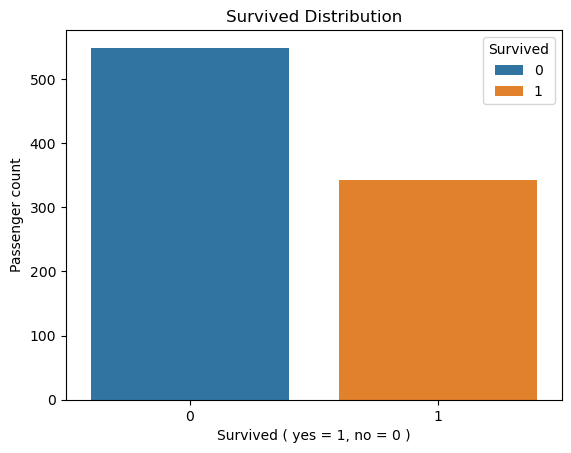

In [35]:
sns.countplot(
    data = df,
    x = "Survived",
    hue = "Survived"
)
plt.title("Survived Distribution")
plt.xlabel("Survived ( yes = 1, no = 0 )")
plt.ylabel("Passenger count")
plt.show()

In [ ]:
# According to plot we can see that more number of pleoples are not survived. Also the data is imbalance so we can use this for the model training.

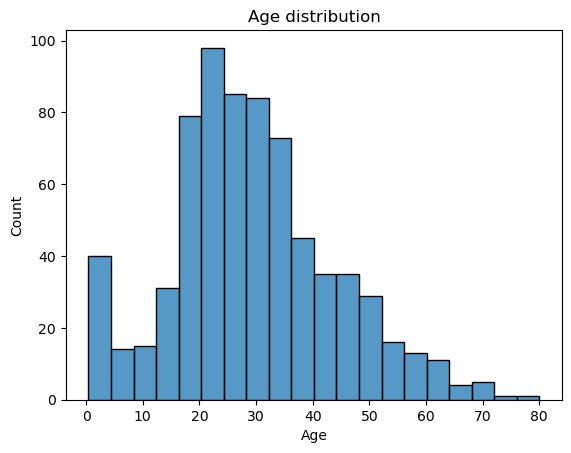

In [14]:
sns.histplot(
    data = df,
    x = "Age"
)
plt.title("Age distribution")
plt.show()

In [15]:
# As from the the histogram plot it clearly see that the more mid age peoples are present on titanic than other age peoples.

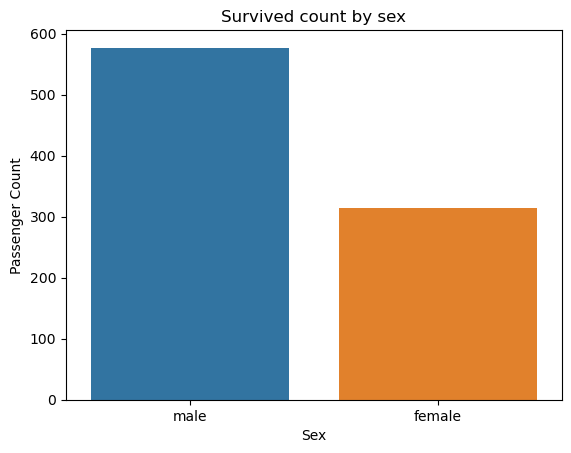

In [16]:
sns.countplot(
    data = df,
    x = "Sex",
    hue = "Sex"
)
plt.title("Survived count by sex")
plt.xlabel("Sex")
plt.ylabel("Passenger Count")
plt.show()

In [17]:
# As clearly sees that more number of male persons are present on titanic than female. so we can use for model training.

In [18]:
title_mapping = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
        'Dr': 'Rare', 'Rev': 'Rare', 'Col': 'Rare', 'Major': 'Rare',
        'Mlle': 'Miss', 'Ms': 'Miss', 'Lady': 'Rare', 'Sir': 'Rare',
        'Mme': 'Mrs', 'Don': 'Rare', 'Capt': 'Rare', 'Countess': 'Rare',
        'Jonkheer': 'Rare', 'Dona': 'Rare'
}

In [19]:
def extract_title(name):
    for title in title_mapping:
        if title + "." in name:
            return title_mapping[title]
    return "Rare"

In [20]:
df["Title"] = df["Name"].apply(extract_title)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr


In [21]:
df["Age"] = df.groupby("Title")["Age"].transform(
    lambda x : x.fillna(x.median())
)

In [60]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [61]:
df["TicketSize"] = df.groupby("Ticket")["Ticket"].transform("count")

In [62]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

In [34]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,TicketSize,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,1,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,1,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,1,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,1,1,1


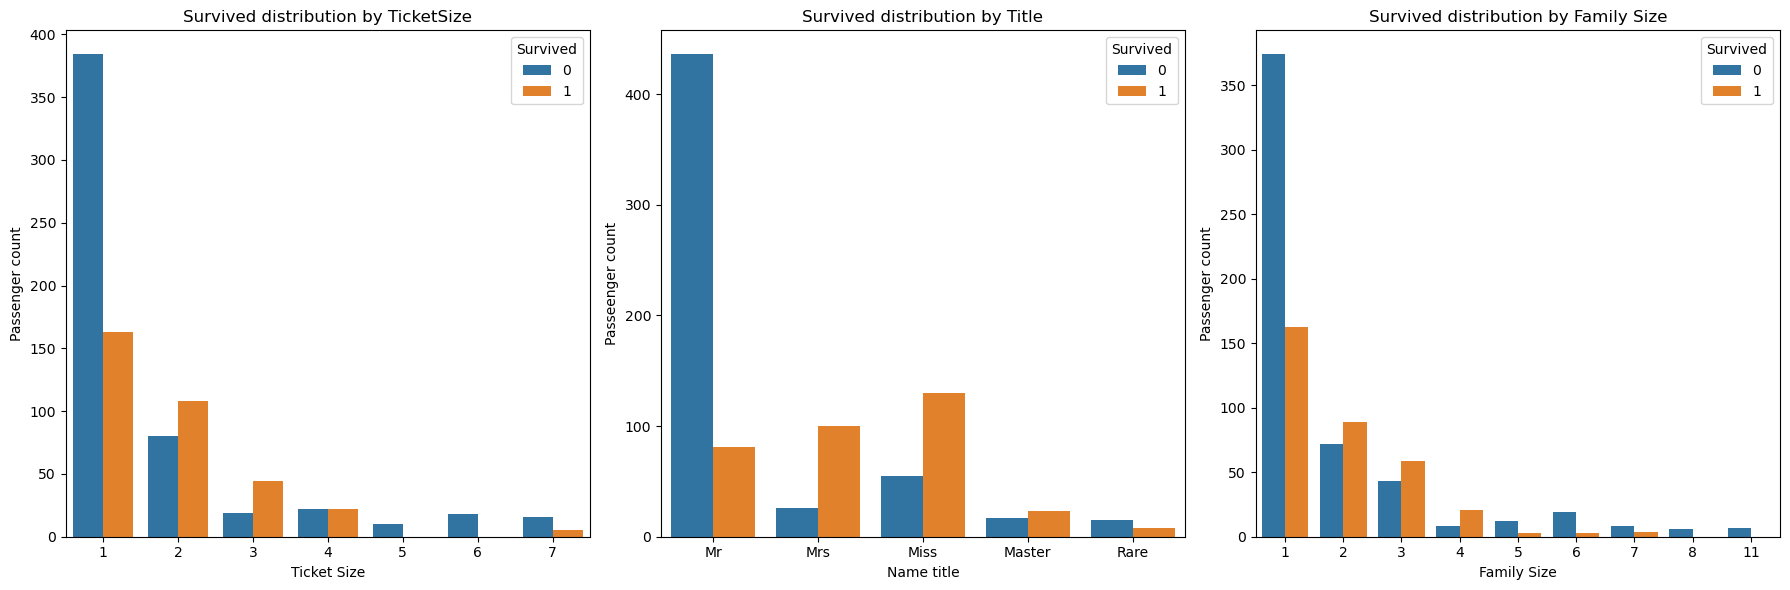

In [40]:
fig, ax = plt.subplots(1,3, figsize=(18,6))

sns.countplot(
    data = df,
    x = "TicketSize",
    hue = "Survived",
    ax = ax[0]
)
ax[0].set_title("Survived distribution by TicketSize")
ax[0].set_xlabel("Ticket Size")
ax[0].set_ylabel("Passenger count")

sns.countplot(
    data = df,
    x = "Title",
    hue = "Survived",
    ax = ax[1]
)
ax[1].set_title("Survived distribution by Title")
ax[1].set_xlabel("Name title")
ax[1].set_ylabel("Passeenger count")

sns.countplot(
    data = df,
    x = "FamilySize",
    hue = "Survived",
    ax = ax[2]
)
ax[2].set_title("Survived distribution by Family Size")
ax[2].set_xlabel("Family Size")
ax[2].set_ylabel("Passenger count")

plt.tight_layout()
plt.show()

In [37]:
#Ticket Size : Examines how survival varies with the number of passengers sharing the same ticket, highlighting group travel effects.
#Name Title : Displays survival rates across passenger titles, capturing socio-demographic differences.
#Family Size: Shows survival counts by family size, helping identify the impact of traveling alone versus with family.

In [63]:
df1 = df.drop(columns = ["PassengerId", "Name", "SibSp", "Parch", "Ticket", "Cabin"])
df1.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,TicketSize,FamilySize,IsAlone
0,0,3,male,22.0,7.2500,S,Mr,1,2,0
1,1,1,female,38.0,71.2833,C,Mrs,1,2,0
2,1,3,female,26.0,7.9250,S,Miss,1,1,1
3,1,1,female,35.0,53.1000,S,Mrs,2,2,0
4,0,3,male,35.0,8.0500,S,Mr,1,1,1


In [64]:
df1["Sex"] = df1["Sex"].map({"male" : 1, "female" : 0})
df1["Embarked"] = df1["Embarked"].map({"S" : 1, "C" : 0})
df1.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,TicketSize,FamilySize,IsAlone
0,0,3,1,22.0,7.2500,1.0,Mr,1,2,0
1,1,1,0,38.0,71.2833,0.0,Mrs,1,2,0
2,1,3,0,26.0,7.9250,1.0,Miss,1,1,1
3,1,1,0,35.0,53.1000,1.0,Mrs,2,2,0
4,0,3,1,35.0,8.0500,1.0,Mr,1,1,1


In [65]:
dummies = pd.get_dummies(df1["Title"]).astype(int)
dummies.head()

,Master,Miss,Mr,Mrs,Rare
0,0,0,1,0,0
1,0,0,0,1,0
2,0,1,0,0,0
3,0,0,0,1,0
4,0,0,1,0,0


In [73]:
df2 = pd.concat([df1.drop(columns = "Title"), dummies], axis = "columns")
df2["Embarked"] = df2["Embarked"].fillna(df2["Embarked"].mode()[0])
df2

,Survived,Pclass,Sex,Age,Fare,Embarked,TicketSize,FamilySize,IsAlone,Master,Miss,Mr,Mrs,Rare
0,0,3,1,22.0,7.2500,1.0,1,2,0,0,0,1,0,0
1,1,1,0,38.0,71.2833,0.0,1,2,0,0,0,0,1,0
2,1,3,0,26.0,7.9250,1.0,1,1,1,0,1,0,0,0
3,1,1,0,35.0,53.1000,1.0,2,2,0,0,0,0,1,0
4,0,3,1,35.0,8.0500,1.0,1,1,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,13.0000,1.0,1,1,1,0,0,0,0,1
887,1,1,0,19.0,30.0000,1.0,1,1,1,0,1,0,0,0
888,0,3,0,21.0,23.4500,1.0,2,4,0,0,1,0,0,0
889,1,1,1,26.0,30.0000,0.0,1,1,1,0,0,1,0,0


In [87]:
X = df2.drop(columns = "Survived")
y = df2["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [88]:
y_pred = model.predict(X_test_scaled)

In [90]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.85      0.84       105
           1       0.78      0.76      0.77        74

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

